# Assignment 1: Hello, Graph World

**DATA620 – Web Analytics | Summer 2026**  
**Zoran Glisovic**

---

This notebook builds the **Krackhardt kite** — a small, named reference graph introduced by organizational theorist David Krackhardt to illustrate different types of influence in social networks. It has 10 nodes and 18 edges, and is commonly used as a starting point in network analysis courses because its structure is compact but non-trivial.

The library used is **NetworkX**, a Python package for creating, analyzing, and visualizing graphs and networks.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

## 1. Build the Graph

The graph represents a small organization. Each person is a **node**, and a social connection between two people is an **edge**. The graph is **undirected** — a connection between Andre and Beverly is the same regardless of which direction you read it.

Nodes and edges are added explicitly, matching the structure shown in the assignment diagram.

In [2]:
# Create an empty undirected graph
kite = nx.Graph(name="Krackhardt Kite")

# Add the 10 people as nodes
kite.add_nodes_from([
    "Andre", "Beverly", "Carol", "Diane",
    "Ed", "Fernando", "Garth", "Heather", "Ike", "Jane"
])

# Add the 18 relationships as edges
kite.add_edges_from([
    ("Andre",    "Beverly"),
    ("Andre",    "Carol"),
    ("Andre",    "Diane"),
    ("Andre",    "Fernando"),
    ("Beverly",  "Diane"),
    ("Beverly",  "Ed"),
    ("Beverly",  "Garth"),
    ("Carol",    "Diane"),
    ("Carol",    "Fernando"),
    ("Diane",    "Ed"),
    ("Diane",    "Fernando"),
    ("Diane",    "Garth"),
    ("Ed",       "Garth"),
    ("Fernando", "Garth"),
    ("Fernando", "Heather"),
    ("Garth",    "Heather"),
    ("Heather",  "Ike"),
    ("Ike",      "Jane")
])

print(f"{kite.name}: {kite.number_of_nodes()} nodes, {kite.number_of_edges()} edges")

Krackhardt Kite: 10 nodes, 18 edges


## 2. Plot the Graph — Manual Layout

Node positions are set manually to match the layout from the assignment diagram. This makes it easy to compare the output visually against the reference.

A few intentional choices in the visualization:
- **Edges are drawn first**, then nodes are layered on top so the lines don't obscure the circles
- **Labels use a semi-transparent white background** to stay readable even when text extends beyond the node boundary
- **Node outlines** (`edgecolors`) are drawn in a darker shade to give the nodes a clean border

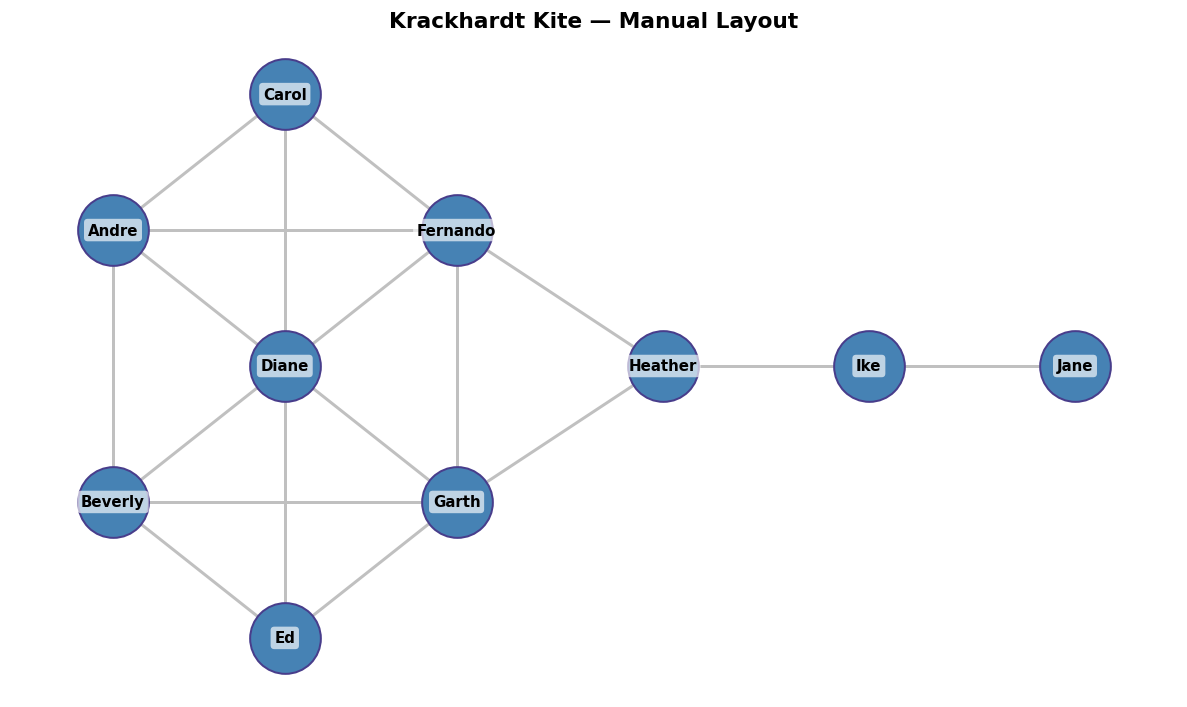

In [3]:
# Fixed positions matching the assignment diagram
pos_manual = {
    "Carol":    (1.0, 4.0),
    "Andre":    (0.0, 3.0),
    "Fernando": (2.0, 3.0),
    "Diane":    (1.0, 2.0),
    "Beverly":  (0.0, 1.0),
    "Garth":    (2.0, 1.0),
    "Ed":       (1.0, 0.0),
    "Heather":  (3.2, 2.0),
    "Ike":      (4.4, 2.0),
    "Jane":     (5.6, 2.0),
}

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Draw edges, then nodes on top
nx.draw_networkx_edges(kite, pos_manual, ax=ax, edge_color="silver", width=1.8)
nx.draw_networkx_nodes(kite, pos_manual, ax=ax, node_color="steelblue",
                       node_size=1800, edgecolors="darkslateblue", linewidths=1.2)

# Labels with a white backdrop so they're readable over any surface
nx.draw_networkx_labels(kite, pos_manual, ax=ax, font_size=9, font_color="black",
                        font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                  alpha=0.65, edgecolor="none"))

ax.set_title("Krackhardt Kite — Manual Layout", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Plot the Graph — Automatic Layout

When working with your own data and no reference diagram exists, node positions need to be calculated automatically. NetworkX includes several layout algorithms for this.

`spring_layout` (Fruchterman-Reingold) is the most commonly used — it treats edges like springs and nodes like magnets that repel each other, settling into a position where connected nodes cluster together. A fixed `seed` is passed so the layout is reproducible across runs.

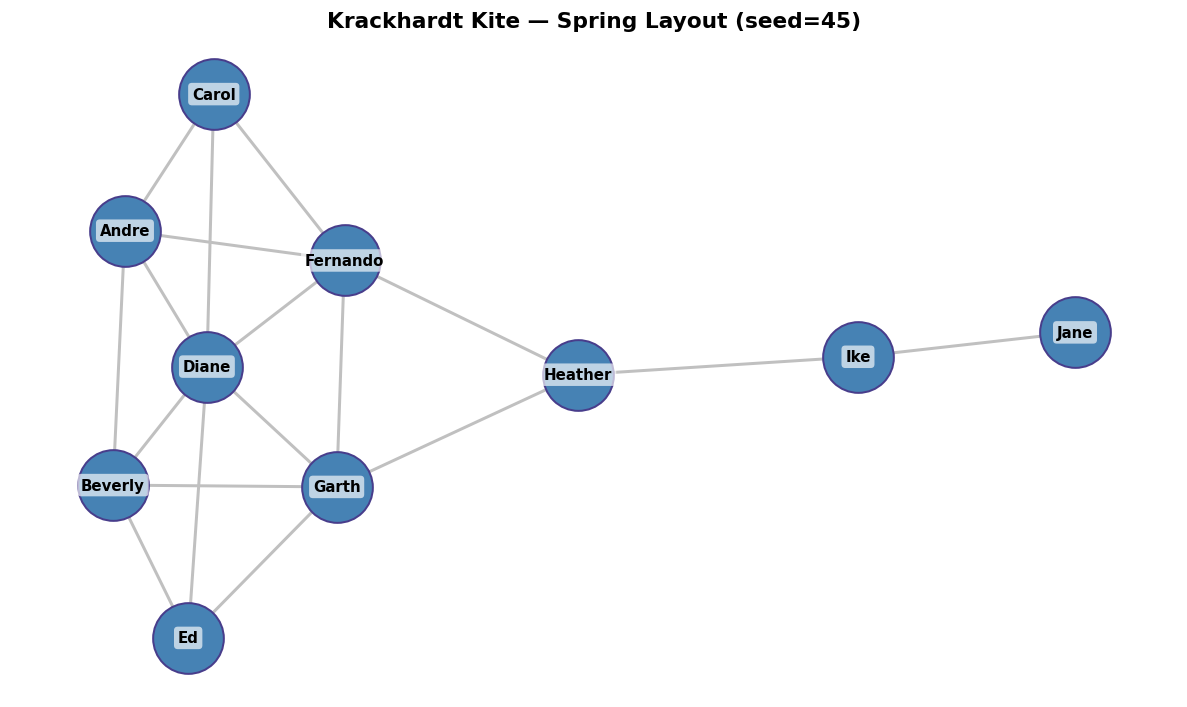

In [4]:
# Change this value to get a different layout
seed = 45

# Automatically calculate node positions based on graph structure
pos_auto = nx.spring_layout(kite, seed=seed)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

nx.draw_networkx_edges(kite, pos_auto, ax=ax, edge_color="silver", width=1.8)
nx.draw_networkx_nodes(kite, pos_auto, ax=ax, node_color="steelblue",
                       node_size=1800, edgecolors="darkslateblue", linewidths=1.2)
nx.draw_networkx_labels(kite, pos_auto, ax=ax, font_size=9, font_color="black",
                        font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                  alpha=0.65, edgecolor="none"))

ax.set_title(f"Krackhardt Kite — Spring Layout (seed={seed})", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

The plot matches the reference diagram from the assignment. The left side of the graph is densely connected — most people there have ties to several others. On the right, Heather connects that dense group to Ike and Jane, who are linked only through that single chain. This kind of structure, where one node is the only path between two parts of a network, is something we'll explore more formally later in the course.